In [21]:
import torch
import os
import matplotlib.pyplot as plt
import PIL #pillow for loading images
import random

import torch
import torchvision.transforms
import torchvision.transforms.functional  #Compose

In [14]:
from torch.utils.data import DataLoader
import torchvision

In [18]:
from torchvision import datasets #ImageFolder

In [24]:
test_normal="data/chest_xray/test/NORMAL"
test_pneumonia="data/chest_xray/test/PNEUMONIA"

In [25]:
test_normal_images=os.listdir(test_normal)
test_pneumonia_images=os.listdir(test_pneumonia)

test_normal_random=random.sample(test_normal_images,3)
test_pneumonia_random=random.sample(test_pneumonia_images,3)

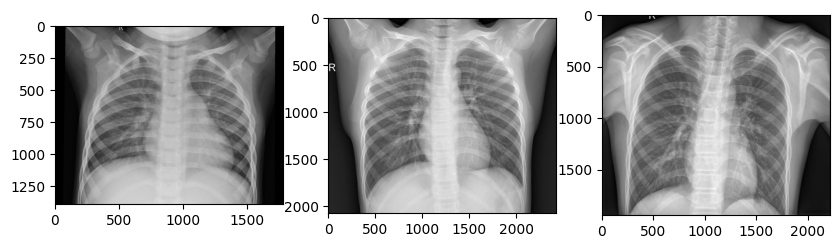

In [31]:
fig,axes=plt.subplots(1,3,figsize=(10,5))
i=0
for img in test_normal_random:
    img=PIL.Image.open(f"{test_normal}/{img}")
    axes[i].imshow(img,cmap='grey')
    i=i+1
    


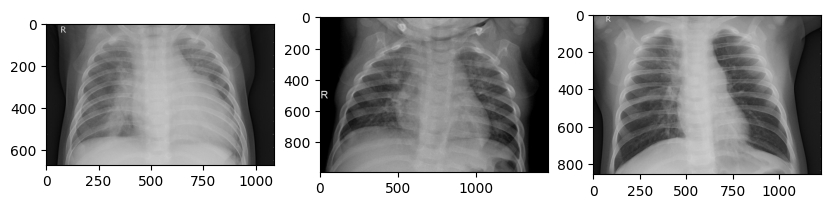

In [36]:
fig,axes=plt.subplots(1,3,figsize=(10,5))
j=0
for img in test_pneumonia_random:
    img=PIL.Image.open(f"{test_pneumonia}/{img}")
    axes[j].imshow(img,cmap='grey')
    j=j+1

In [43]:
# from torchvision import transforms

from torchvision.transforms import v2  #Using v2 as its faster

val_test_transform = v2.Compose([
    v2.Lambda(lambda x: x.convert('RGB')),
    v2.Resize((224, 224)),
    v2.ToTensor(),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])



train_transform=v2.Compose([
    v2.Lambda(lambda x:x.convert('RGB')),
    v2.Resize((224,224)),
    #Data Augmentation -> Rotation,Scaling etc
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation((-10,10)),
    v2.ToTensor(),
    v2.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])

])




c:\chest-xray-ai\venv\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [44]:
from torchvision.datasets import ImageFolder


In [51]:
train_dataset=ImageFolder(root="data/chest_xray/train",transform=train_transform)
test_dataset=ImageFolder(root="data/chest_xray/test",transform=val_test_transform)
val_dataset=ImageFolder(root="data/chest_xray/val",transform=val_test_transform)

In [53]:
print(len(train_dataset))
print(len(test_dataset))
print(len(val_dataset))
print(train_dataset.classes)

5216
624
16
['NORMAL', 'PNEUMONIA']


In [55]:
# DataLoader
from torch.utils.data import DataLoader

train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=32,shuffle=False)

In [56]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels)

torch.Size([32, 3, 224, 224])
tensor([0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1,
        0, 1, 0, 0, 1, 1, 1, 1])


In [59]:
from torchvision.models import resnet50

In [62]:
model=resnet50()

In [63]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [64]:
from torch import nn

model.fc=nn.Linear(in_features=2048,out_features=2,bias=True)

In [65]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [75]:
for param in model.parameters():
    if(param!='fc'):
        param.requires_grad=False


for param in model.fc.parameters():
    param.requires_grad = True

In [78]:
for name,param in model.named_parameters():
    print(name,param.requires_grad)

conv1.weight False
bn1.weight False
bn1.bias False
layer1.0.conv1.weight False
layer1.0.bn1.weight False
layer1.0.bn1.bias False
layer1.0.conv2.weight False
layer1.0.bn2.weight False
layer1.0.bn2.bias False
layer1.0.conv3.weight False
layer1.0.bn3.weight False
layer1.0.bn3.bias False
layer1.0.downsample.0.weight False
layer1.0.downsample.1.weight False
layer1.0.downsample.1.bias False
layer1.1.conv1.weight False
layer1.1.bn1.weight False
layer1.1.bn1.bias False
layer1.1.conv2.weight False
layer1.1.bn2.weight False
layer1.1.bn2.bias False
layer1.1.conv3.weight False
layer1.1.bn3.weight False
layer1.1.bn3.bias False
layer1.2.conv1.weight False
layer1.2.bn1.weight False
layer1.2.bn1.bias False
layer1.2.conv2.weight False
layer1.2.bn2.weight False
layer1.2.bn2.bias False
layer1.2.conv3.weight False
layer1.2.bn3.weight False
layer1.2.bn3.bias False
layer2.0.conv1.weight False
layer2.0.bn1.weight False
layer2.0.bn1.bias False
layer2.0.conv2.weight False
layer2.0.bn2.weight False
layer2.0.bn2

In [ ]:
import torch.nn as nn
import torch.optim as optim # Adam Optimizer

In [83]:
loss_function=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.fc.parameters(),lr=0.001)

In [ ]:
# Model Training



# train_normal="data/chest_xray/train/NORMAL"
# train_pneumonia="data/chest_xray/train/PNEUMONIA"

# train_normal_images=os.listdir(train_normal)
# train_pneumonia_images=os.listdir(train_pneumonia)

for img,label in train_loader:
    optimizer.zero_grad() #Nullifying the previous batch gradients
    output=model(img)
    loss=loss_function(output,label)
    loss.backward() # Backpropogation
    # update weight
    optimizer.step()

